In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create the data from your table
data = {
    'Query': ['SF1', 'SF1', 'SF2', 'SF2', 'SF3', 'SF3', 'SF4', 'SF4', 'SF5', 'SF5'] * 2,
    'Subset': ['Q1', 'Q2', 'Q1', 'Q2', 'Q1', 'Q2', 'Q1', 'Q2', 'Q1', 'Q2'] * 2,
    'AUC': [0.67, 0.88, 0.75, 0.88, 0.52, 0.79, 0.82, 0.76, 0.56, 0.53] * 2,
    'TOP_1_EF': [2.75, 34.76, 11.01, 35.45, 0.86, 9.81, 20.65, 13.42, 1.2, 0.02] + [np.nan] * 10,
    'TOP_1_BEDROC': [0.08, 0.65, 0.33, 0.64, 0.02, 0.19, 0.45, 0.29, 0.03, 0.02] + [np.nan] * 10,
    'TOP_1_CCR': [0.5, 0.63, 0.53, 0.62, 0.5, 0.52, 0.54, 0.53, 0.5, 0.5] + [np.nan] * 10,
    'TOP_5_EF': [np.nan] * 10 + [2.58, 3.17, 4.16, 13.42, 0.92, 8.33, 8.57, 7.12, 0.96, 0.75],
    'TOP_5_BEDROC': [np.nan] * 10 + [0.11, 0.62, 0.23, 0.66, 0.04, 0.34, 0.43, 0.31, 0.05, 0.03],
    'TOP_5_CCR': [np.nan] * 10 + [0.52, 0.71, 0.56, 0.7, 0.5, 0.6, 0.6, 0.57, 0.5, 0.5],
    'TOP_10_EF': [np.nan] * 10 + [2.01, 7.57, 3.32, 7.5, 0.87, 5.59, 5.57, 4.97, 1.17, 0.79],
    'TOP_10_BEDROC': [np.nan] * 10 + [0.16, 0.65, 0.29, 0.69, 0.07, 0.43, 0.48, 0.39, 0.08, 0.06],
    'TOP_10_CCR': [np.nan] * 10 + [0.53, 0.74, 0.59, 0.73, 0.5, 0.63, 0.64, 0.6, 0.51, 0.5],
    'Percentage': ['TOP 1%'] * 10 + ['TOP 5%'] * 10
}

# Remove the duplicate rows and create proper structure
df_raw = pd.DataFrame({
    'Query': ['SF1', 'SF1', 'SF2', 'SF2', 'SF3', 'SF3', 'SF4', 'SF4', 'SF5', 'SF5'],
    'Subset': ['Q1', 'Q2', 'Q1', 'Q2', 'Q1', 'Q2', 'Q1', 'Q2', 'Q1', 'Q2'],
    'AUC': [0.67, 0.88, 0.75, 0.88, 0.52, 0.79, 0.82, 0.76, 0.56, 0.53],
    'TOP_1_EF': [2.75, 34.76, 11.01, 35.45, 0.86, 9.81, 20.65, 13.42, 1.2, 0.02],
    'TOP_1_BEDROC': [0.08, 0.65, 0.33, 0.64, 0.02, 0.19, 0.45, 0.29, 0.03, 0.02],
    'TOP_1_CCR': [0.5, 0.63, 0.53, 0.62, 0.5, 0.52, 0.54, 0.53, 0.5, 0.5],
    'TOP_5_EF': [2.58, 3.17, 4.16, 13.42, 0.92, 8.33, 8.57, 7.12, 0.96, 0.75],
    'TOP_5_BEDROC': [0.11, 0.62, 0.23, 0.66, 0.04, 0.34, 0.43, 0.31, 0.05, 0.03],
    'TOP_5_CCR': [0.52, 0.71, 0.56, 0.7, 0.5, 0.6, 0.6, 0.57, 0.5, 0.5],
    'TOP_10_EF': [2.01, 7.57, 3.32, 7.5, 0.87, 5.59, 5.57, 4.97, 1.17, 0.79],
    'TOP_10_BEDROC': [0.16, 0.65, 0.29, 0.69, 0.07, 0.43, 0.48, 0.39, 0.08, 0.06],
    'TOP_10_CCR': [0.53, 0.74, 0.59, 0.73, 0.5, 0.63, 0.64, 0.6, 0.51, 0.5]
})

print("Data loaded successfully!")
print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Data loaded successfully!
Dataset shape: (10, 12)


,Query,Subset,AUC,TOP_1_EF,TOP_1_BEDROC,TOP_1_CCR,TOP_5_EF,TOP_5_BEDROC,TOP_5_CCR,TOP_10_EF,TOP_10_BEDROC,TOP_10_CCR
0,SF1,Q1,0.67,2.75,0.08,0.50,2.58,0.11,0.52,2.01,0.16,0.53
1,SF1,Q2,0.88,34.76,0.65,0.63,3.17,0.62,0.71,7.57,0.65,0.74
2,SF2,Q1,0.75,11.01,0.33,0.53,4.16,0.23,0.56,3.32,0.29,0.59
3,SF2,Q2,0.88,35.45,0.64,0.62,13.42,0.66,0.70,7.50,0.69,0.73
4,SF3,Q1,0.52,0.86,0.02,0.50,0.92,0.04,0.50,0.87,0.07,0.50


In [2]:
# Reshape data for plotting
# Create separate dataframes for each metric and percentage combination

# AUC data (single values, no percentage breakdown)
auc_data = []
for _, row in df_raw.iterrows():
    auc_data.append({
        'Query': row['Query'],
        'Subset': row['Subset'],
        'Metric': 'AUC',
        'Percentage': 'Overall',
        'Score': row['AUC']
    })

# EF, BEDROC, and CCR data for different percentages
ef_bedroc_ccr_data = []
for _, row in df_raw.iterrows():
    # TOP 1%
    ef_bedroc_ccr_data.extend([
        {'Query': row['Query'], 'Subset': row['Subset'], 'Metric': 'EF', 'Percentage': 'TOP 1%', 'Score': row['TOP_1_EF']},
        {'Query': row['Query'], 'Subset': row['Subset'], 'Metric': 'BEDROC', 'Percentage': 'TOP 1%', 'Score': row['TOP_1_BEDROC']},
        {'Query': row['Query'], 'Subset': row['Subset'], 'Metric': 'CCR', 'Percentage': 'TOP 1%', 'Score': row['TOP_1_CCR']}
    ])
    # TOP 5%
    ef_bedroc_ccr_data.extend([
        {'Query': row['Query'], 'Subset': row['Subset'], 'Metric': 'EF', 'Percentage': 'TOP 5%', 'Score': row['TOP_5_EF']},
        {'Query': row['Query'], 'Subset': row['Subset'], 'Metric': 'BEDROC', 'Percentage': 'TOP 5%', 'Score': row['TOP_5_BEDROC']},
        {'Query': row['Query'], 'Subset': row['Subset'], 'Metric': 'CCR', 'Percentage': 'TOP 5%', 'Score': row['TOP_5_CCR']}
    ])
    # TOP 10%
    ef_bedroc_ccr_data.extend([
        {'Query': row['Query'], 'Subset': row['Subset'], 'Metric': 'EF', 'Percentage': 'TOP 10%', 'Score': row['TOP_10_EF']},
        {'Query': row['Query'], 'Subset': row['Subset'], 'Metric': 'BEDROC', 'Percentage': 'TOP 10%', 'Score': row['TOP_10_BEDROC']},
        {'Query': row['Query'], 'Subset': row['Subset'], 'Metric': 'CCR', 'Percentage': 'TOP 10%', 'Score': row['TOP_10_CCR']}
    ])

# Combine all data
all_data = auc_data + ef_bedroc_ccr_data
df_long = pd.DataFrame(all_data)

# Add a combined identifier for better visualization
df_long['Query_Subset'] = df_long['Query'] + '_' + df_long['Subset']

print("Data reshaped successfully!")
print(f"Long format dataset shape: {df_long.shape}")
print(f"Unique metrics: {df_long['Metric'].unique()}")
print(f"Unique percentages: {df_long['Percentage'].unique()}")
df_long

Data reshaped successfully!
Long format dataset shape: (100, 6)
Unique metrics: ['AUC' 'EF' 'BEDROC' 'CCR']
Unique percentages: ['Overall' 'TOP 1%' 'TOP 5%' 'TOP 10%']


,Query,Subset,Metric,Percentage,Score,Query_Subset
0,SF1,Q1,AUC,Overall,0.67,SF1_Q1
1,SF1,Q2,AUC,Overall,0.88,SF1_Q2
2,SF2,Q1,AUC,Overall,0.75,SF2_Q1
3,SF2,Q2,AUC,Overall,0.88,SF2_Q2
4,SF3,Q1,AUC,Overall,0.52,SF3_Q1
...,...,...,...,...,...,...
95,SF5,Q2,BEDROC,TOP 5%,0.03,SF5_Q2
96,SF5,Q2,CCR,TOP 5%,0.50,SF5_Q2
97,SF5,Q2,EF,TOP 10%,0.79,SF5_Q2
98,SF5,Q2,BEDROC,TOP 10%,0.06,SF5_Q2


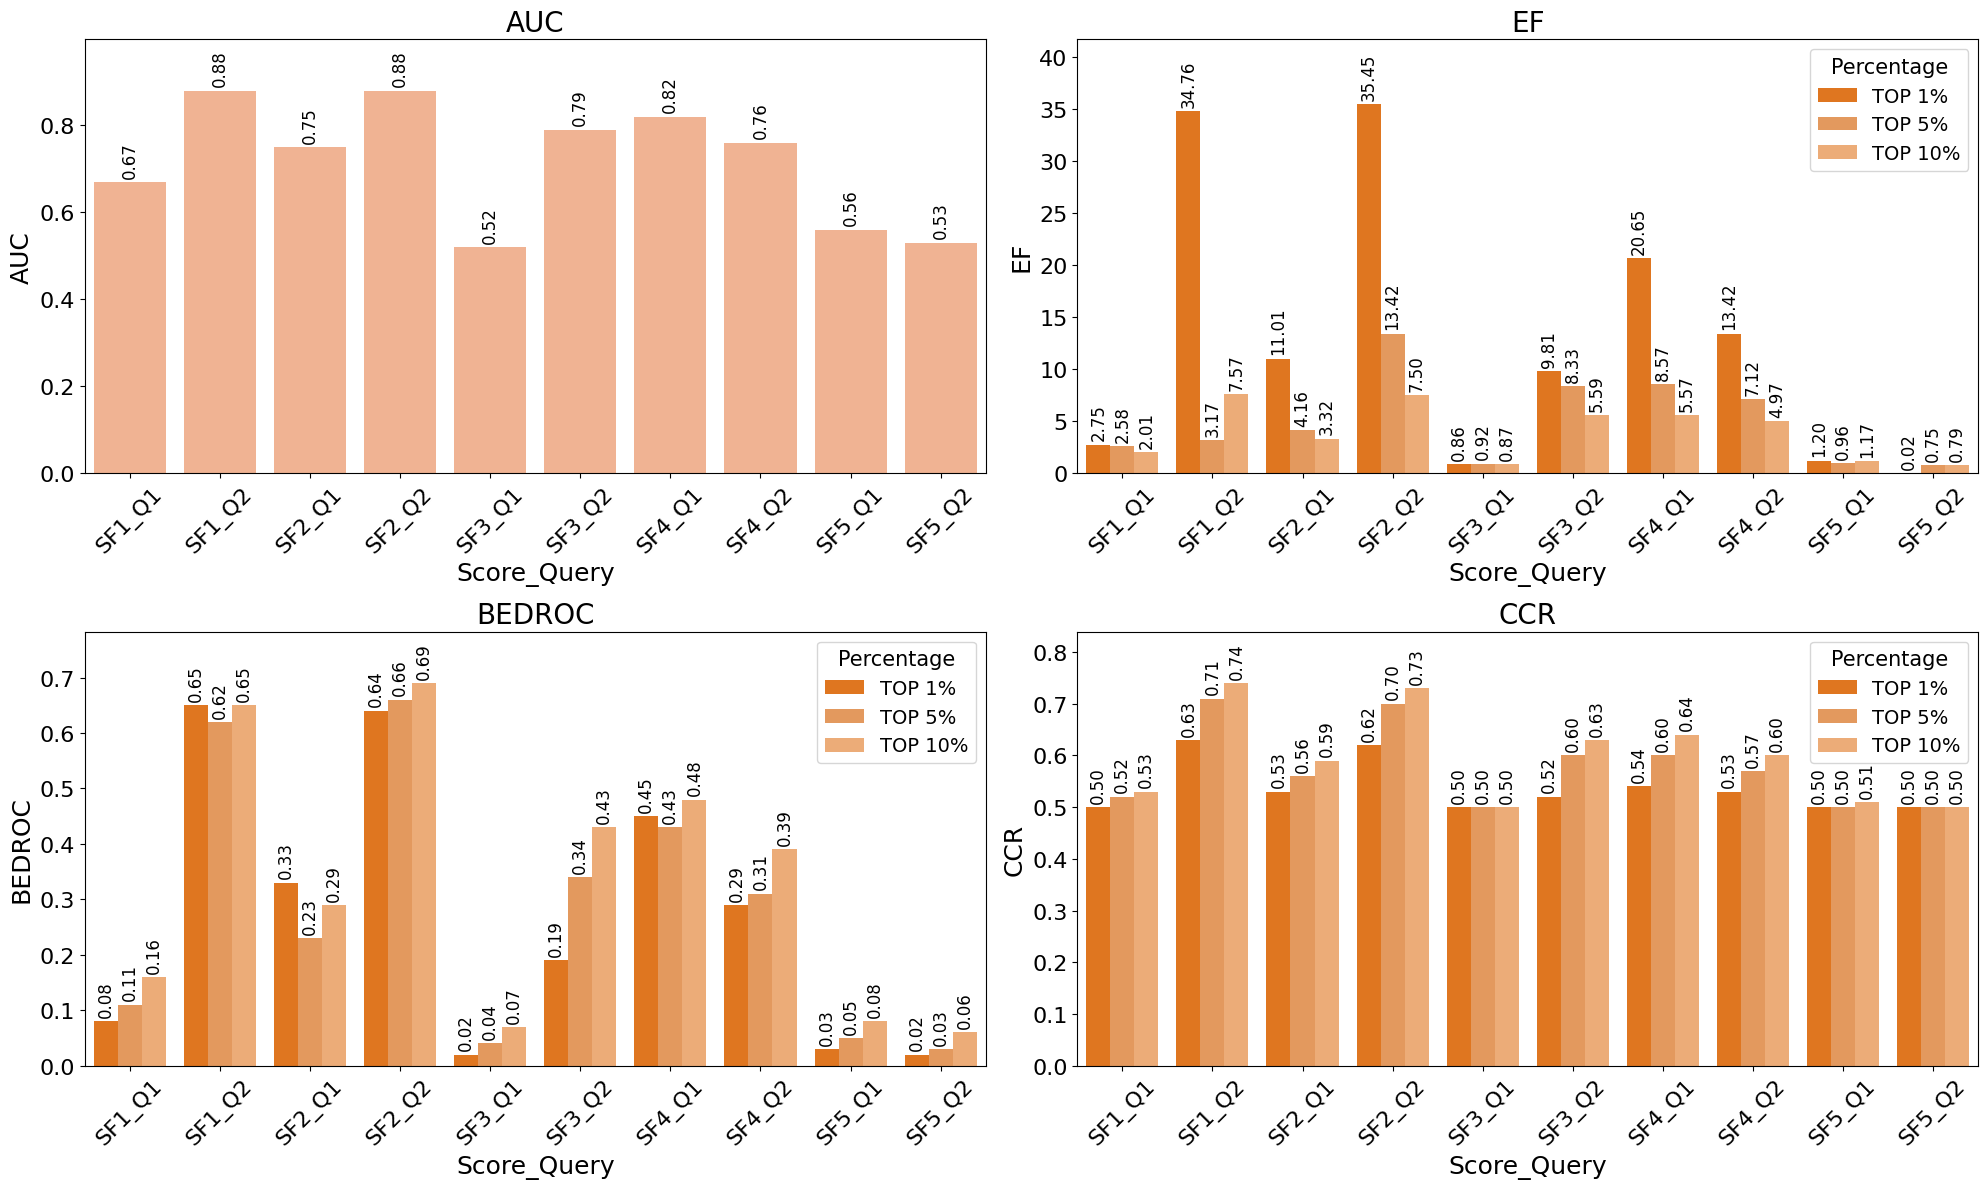

In [4]:
# Create the catplot separated by metrics with numeric labels on each bar
plt.style.use('default')

orange_palette = ["#FF7300", "#F99748", "#FFAA65"]  # consistent orange shades

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

axis_label_fontsize = 18
tick_label_fontsize = 16
title_fontsize = 20
label_fontsize = 12  # numeric labels on bars

def adjust_ylim_for_labels(ax, pad=0.08):
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + (ymax - ymin) * pad)

def annotate_bars(ax, fmt='{:.2f}', pad=0.08, zero_tol=1e-8):
    # Avoid annotating bars with zero height (or extremely close to zero)
    adjust_ylim_for_labels(ax, pad=pad)
    ymin, ymax = ax.get_ylim()
    y_offset = (ymax - ymin) * 0.01
    for p in ax.patches:
        height = p.get_height()
        if np.isnan(height) or np.isclose(height, 0.0, atol=zero_tol) or height <= 0:
            continue
        x = p.get_x() + p.get_width() / 2
        ax.text(x, height + y_offset, fmt.format(height), ha='center', va='bottom', fontsize=label_fontsize, rotation=90)

# AUC Plot (top-left)
auc_df = df_long[df_long['Metric'] == 'AUC']
ax1 = axes[0, 0]
sns.barplot(data=auc_df, x='Query_Subset', y='Score', ax=ax1, color="#FFAE83")
ax1.set_title('AUC', fontsize=title_fontsize)
ax1.set_xlabel('Score_Query', fontsize=axis_label_fontsize)
ax1.set_ylabel('AUC', fontsize=axis_label_fontsize)
ax1.tick_params(axis='x', rotation=45, labelsize=tick_label_fontsize)
ax1.tick_params(axis='y', labelsize=tick_label_fontsize)
annotate_bars(ax1, fmt='{:.2f}')

# EF Plot (top-right)
ef_df = df_long[df_long['Metric'] == 'EF']
ax2 = axes[0, 1]
sns.barplot(data=ef_df, x='Query_Subset', y='Score', hue='Percentage', ax=ax2, palette=orange_palette)
ax2.set_title('EF', fontsize=title_fontsize)
ax2.set_xlabel('Score_Query', fontsize=axis_label_fontsize)
ax2.set_ylabel('EF', fontsize=axis_label_fontsize)
ax2.tick_params(axis='x', rotation=45, labelsize=tick_label_fontsize)
ax2.tick_params(axis='y', labelsize=tick_label_fontsize)
ax2.legend(title='Percentage', loc='upper right', fontsize=14, title_fontsize=15)
annotate_bars(ax2, fmt='{:.2f}', pad=0.12)

# BEDROC Plot (bottom-left)
bedroc_df = df_long[df_long['Metric'] == 'BEDROC']
ax3 = axes[1, 0]
sns.barplot(data=bedroc_df, x='Query_Subset', y='Score', hue='Percentage', ax=ax3, palette=orange_palette)
ax3.set_title('BEDROC', fontsize=title_fontsize)
ax3.set_xlabel('Score_Query', fontsize=axis_label_fontsize)
ax3.set_ylabel('BEDROC', fontsize=axis_label_fontsize)
ax3.tick_params(axis='x', rotation=45, labelsize=tick_label_fontsize)
ax3.tick_params(axis='y', labelsize=tick_label_fontsize)
ax3.legend(title='Percentage', loc='upper right', fontsize=14, title_fontsize=15)
annotate_bars(ax3, fmt='{:.2f}')

# CCR Plot (bottom-right)
ccr_df = df_long[df_long['Metric'] == 'CCR']
ax4 = axes[1, 1]
sns.barplot(data=ccr_df, x='Query_Subset', y='Score', hue='Percentage', ax=ax4, palette=orange_palette)
ax4.set_title('CCR', fontsize=title_fontsize)
ax4.set_xlabel('Score_Query', fontsize=axis_label_fontsize)
ax4.set_ylabel('CCR', fontsize=axis_label_fontsize)
ax4.tick_params(axis='x', rotation=45, labelsize=tick_label_fontsize)
ax4.tick_params(axis='y', labelsize=tick_label_fontsize)
ax4.legend(title='Percentage', loc='upper right', fontsize=14, title_fontsize=15)
annotate_bars(ax4, fmt='{:.2f}')

plt.tight_layout()
plt.show()